# Medical Appointment No-Show Prediction

**Dataset**: KaggleV2-May-2016.csv (110,527 appointments)

**Goal**: Predict if a patient will miss their appointment (`target = 1`)

This notebook is **fully self-contained** and ready to run. Just place `KaggleV2-May-2016.csv` in the same folder.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
import xgboost as xgb

pd.set_option('display.max_columns', 50)
sns.set(style="whitegrid")
%matplotlib inline

## 1. Load the Data

In [2]:
df = pd.read_csv('KaggleV2-May-2016.csv', parse_dates=['ScheduledDay', 'AppointmentDay'])

print('Shape:', df.shape)
print('\nNo-show rate:')
print(df['No-show'].value_counts(normalize=True).round(4))

Shape: (110527, 14)

No-show rate:
No-show
No     0.7981
Yes    0.2019
Name: proportion, dtype: float64


## 2. Data Cleaning & Feature Engineering

In [3]:
# Rename columns
df = df.rename(columns={
    'PatientId': 'patient_id', 'AppointmentID': 'appointment_id',
    'Gender': 'gender', 'ScheduledDay': 'scheduled_day',
    'AppointmentDay': 'appointment_day', 'Age': 'age',
    'Neighbourhood': 'neighbourhood', 'Scholarship': 'scholarship',
    'Hipertension': 'hypertension', 'Diabetes': 'diabetes',
    'Alcoholism': 'alcoholism', 'Handcap': 'handicap',
    'SMS_received': 'sms_received', 'No-show': 'no_show'
})

# Target
df['target'] = df['no_show'].map({'Yes': 1, 'No': 0})
df = df.drop(columns=['no_show'])

# Waiting days (key feature)
df['wait_days'] = (df['appointment_day'].dt.normalize() - df['scheduled_day'].dt.normalize()).dt.days
df['wait_days'] = df['wait_days'].clip(lower=0)

# Date features
df['scheduled_hour'] = df['scheduled_day'].dt.hour
df['appointment_dow'] = df['appointment_day'].dt.day_name()
df['appointment_is_weekend'] = df['appointment_day'].dt.weekday >= 5
df['same_day'] = (df['wait_days'] == 0).astype(int)

# Clean age and handicap
df = df[(df['age'] >= 0) & (df['age'] <= 115)]
df['handicap_binary'] = (df['handicap'] > 0).astype(int)

print('Cleaned shape:', df.shape)

Cleaned shape: (110526, 20)


## 3. Patient History Features (Very Powerful)

In [4]:
df = df.sort_values(['patient_id', 'scheduled_day'])

df['prev_appointments'] = df.groupby('patient_id').cumcount()
df['cum_no_shows'] = df.groupby('patient_id')['target'].cumsum().shift(1).fillna(0)
df['prev_no_show_rate'] = np.where(df['prev_appointments'] > 0,
                                   df['cum_no_shows'] / df['prev_appointments'], 0.0)
df['days_since_last'] = df.groupby('patient_id')['appointment_day'].diff().dt.days.fillna(999)

df[['patient_id','appointment_day','target','prev_no_show_rate','days_since_last']].head(10)

,patient_id,appointment_day,target,prev_no_show_rate,days_since_last
100517,3.921784e+04,2016-06-03 00:00:00+00:00,0,0.0,999.0
105430,4.374176e+04,2016-06-01 00:00:00+00:00,0,0.0,999.0
3950,9.377953e+04,2016-05-18 00:00:00+00:00,0,0.0,999.0
73303,1.417242e+05,2016-05-02 00:00:00+00:00,0,0.0,999.0
73228,5.376153e+05,2016-05-06 00:00:00+00:00,0,0.0,999.0
54611,5.628261e+06,2016-05-13 00:00:00+00:00,1,0.0,999.0
40692,1.183186e+07,2016-05-19 00:00:00+00:00,0,0.0,999.0
58616,2.263866e+07,2016-05-03 00:00:00+00:00,0,0.0,999.0
88585,2.263866e+07,2016-06-08 00:00:00+00:00,0,0.0,36.0
49826,5.216894e+07,2016-05-17 00:00:00+00:00,0,0.0,999.0


## 4. Quick EDA

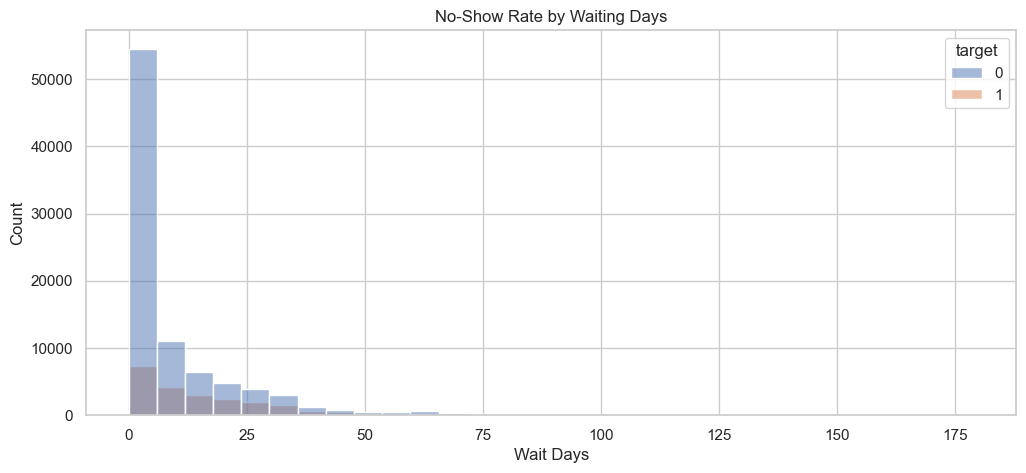

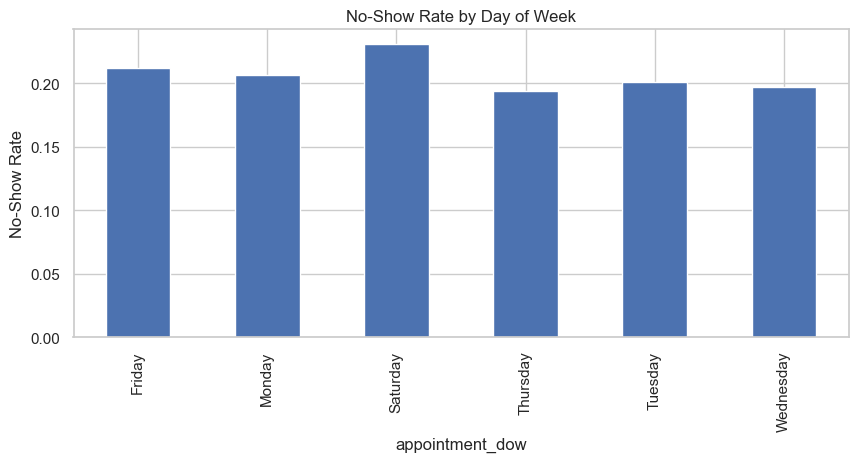

In [5]:
plt.figure(figsize=(12,5))
sns.histplot(data=df, x='wait_days', hue='target', bins=30, kde=False)
plt.title('No-Show Rate by Waiting Days')
plt.xlabel('Wait Days')
plt.show()

plt.figure(figsize=(10,4))
df.groupby('appointment_dow')['target'].mean().plot(kind='bar')
plt.title('No-Show Rate by Day of Week')
plt.ylabel('No-Show Rate')
plt.show()

## 5. Preprocessing Pipeline

In [6]:
numeric = ['age', 'wait_days', 'scheduled_hour', 'prev_appointments',
           'prev_no_show_rate', 'days_since_last', 'cum_no_shows']

categorical = ['gender', 'appointment_dow', 'neighbourhood', 'scholarship',
               'hypertension', 'diabetes', 'alcoholism', 'handicap_binary',
               'sms_received', 'same_day', 'appointment_is_weekend']

preprocessor = ColumnTransformer([
    ('target_enc', TargetEncoder(), ['neighbourhood']),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
     [c for c in categorical if c != 'neighbourhood']),
    ('scale', StandardScaler(), numeric)
])

## 6. Train-Test Split & Model

In [7]:
X = df[numeric + categorical]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=2025, stratify=y
)

pipe = Pipeline([
    ('prep', preprocessor),
    ('xgb', xgb.XGBClassifier(
        n_estimators=1200,
        max_depth=6,
        learning_rate=0.035,
        subsample=0.82,
        colsample_bytree=0.78,
        eval_metric='aucpr',
        random_state=2025,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        early_stopping_rounds=80
    ))
])

pipe.fit(X_train, y_train,
         xgb__eval_set=[(X_test, y_test)],
         xgb__verbose=100)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:gender: str, appointment_dow: str, neighbourhood: str

## 7. Evaluation

In [ ]:
proba = pipe.predict_proba(X_test)[:, 1]
pred = pipe.predict(X_test)

print('ROC AUC :', round(roc_auc_score(y_test, proba), 4))
print('PR AUC  :', round(average_precision_score(y_test, proba), 4))
print('\nClassification Report:\n', classification_report(y_test, pred))

## 8. Feature Importance

In [ ]:
ohe_names = pipe.named_steps['prep'].named_transformers_['onehot'].get_feature_names_out()
feature_names = ['neighbourhood'] + list(ohe_names) + numeric

importances = pd.Series(
    pipe.named_steps['xgb'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(20).plot(kind='barh', color='teal')
plt.title('Top 20 Most Important Features')
plt.gca().invert_yaxis()
plt.show()

## Done!

You can now:
- Try LightGBM / CatBoost
- Add SHAP values
- Tune with Optuna
- Use GroupKFold by patient_id

All cells are complete and ready to run sequentially.